# SC OT with Thresholds
Due to the nature of the sc data, there are many low values present. Here, we'll investigate the general distribution of the sc data, identify an applicable threshold and test the ability of OT to differentiate between cell types once again using these thresholds.

## Imports

In [1]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, bin_contact_map, hic_ot_source_to_targets, hic_mask_threshold

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

# Saving metadata
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')

## Helper Functions

In [2]:
def map_cell_types(data: pd.DataFrame):
    '''
        Transforms fille name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def generate_ot_data(source_cell_type: str, res: int=8, thres: float=0, cell_count: int=20):
    '''
        Generates the OT data needed for the approach taken here

        This function is very specific to this notebook.

        Parameters
        ----------
        source_cell_type : str
            The cell type to be compared to all other cell types.
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        thres : float
            Threshold to use for OT (percentile).
        cell_count : int
            The top number of cells to be used.
            Default = 20.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    ### Importing Data ###    
    # Metadata
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), cell_count),
                    replace=False,
                    random_state=42
                ))
                .reset_index(drop=True)
    )
    targets = list(sampled_files["cell_name"])
    sources = list(sampled_files[sampled_files["cell_type"] == source_cell_type]["cell_name"])

    # Coolers
    target_clrs = import_cool_dir(sc_dir, include=targets)
    source_clrs = import_cool_dir(sc_dir, include=sources)

    ### Performing OT ###
    # Saving directory
    ot_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

    # Prepping data
    target_chr1s = []
    target_names = []

    for clr in target_clrs:
        target_chr1s.append(fetch_region(clr, "chr1"))
        target_names.append(get_cool_name(clr))

    source_chr1s = []
    source_names = []

    for clr in source_clrs:
        source_chr1s.append(fetch_region(clr, "chr1"))
        source_names.append(get_cool_name(clr))

    # Binning
    target_chr1s_binned = []
    for chr1 in target_chr1s:
        target_chr1s_binned.append(bin_contact_map(chr1, res))

    source_chr1s_binned = []
    for chr1 in source_chr1s:
        source_chr1s_binned.append(bin_contact_map(chr1, res))

    # OT
    ot_results_list = []
    for map in source_chr1s_binned:
        ot_results_list.append(hic_ot_source_to_targets(map, target_chr1s_binned, thres, "percentile", "sum"))

    # Transform to dataframe
    ot_results_df = pd.DataFrame(ot_results_list, index=source_names, columns=target_names)

    # Saving
    ot_results_df.to_csv(f'{ot_save_dir}/{source_cell_type}_type_clustering_ot_{res}mb_{thres}_{cell_count}.csv')

    ### Transforming to long format ###
    ot_results_long = map_cell_types(ot_results_df)

    return ot_results_long

def ot_full_cell_type_comparison(res: int=8, thres: float=0, cell_count: int=20):
    '''
        Takes a resolution, threshold and cell count and performs
        OT between the top number of specified cells per cell type.
        Returns the data in a long format.

        This function is specific to this notebook.

        Parameters
        ----------
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        thres : float
            Threshold to use for OT (percentile).
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        
        Returns
        -------
        ot_compare_long : pd.DataFrame
            Long format dataframe
    '''
    # Loop through all cell types
    cell_types = metadata["cell_type"].unique()

        # Looping over cell types
    ot_long_dfs = []
    for ct in cell_types:
        ot_long_dfs.append(generate_ot_data(ct, res, thres, cell_count))
    
        # Concatenating 
    ot_compare_long = pd.concat(ot_long_dfs)

    return ot_compare_long

def generate_heatmap(long_df: pd.DataFrame, res: int, thres: float, cell_count: int):
    '''
        Takes long format dataframe generated from ot_full_cell_type_comparison()
        and generate a heatmap.

        This function is specifc to this notebook.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe to be visualized.
        res : int
            Resolution used for analysis. Used for figure title.
        thres : float
            Threshold used for analysis. Used for figure title.
        cell_count : int
            Top number of cells used for analysis. Used for figure
            title.
    '''
    # Calculating means
    ot_mean_matrix = long_df.groupby(
        ['row_cell_type', 'col_cell_type']
    )["value"].mean()

    # Showing heatmap
    ot_heatmap_df = ot_mean_matrix.unstack()
    plt.figure(figsize=(8, 6))
    sns.heatmap(ot_heatmap_df, annot=True, cmap='viridis', fmt=".0f")
    plt.title(f'Mean Chr1 OT Loss Across Cell-Type Pairs (Top {cell_count}, {res} Mb, {thres}%)')
    plt.show()
    return

## Investigating Data Distribution

In [11]:
### Importing data ###
    # Import cools
sc_cools = import_cool_dir(sc_dir)

    # Extract chr1
sc_chr1s = []
for clr in sc_cools:
    sc_chr1s.append(fetch_region(clr, 'chr1'))
del sc_cools

In [12]:
### Combining into one dataframe ###
combined_values = []

rows, cols = np.tril_indices_from(sc_chr1s[0], k=1)

for chr1 in sc_chr1s:
    combined_values.append(chr1[rows, cols])

combined_values = np.concatenate(combined_values)
non_zero = combined_values[combined_values > 0]

Text(0, 0.5, 'Frequency')

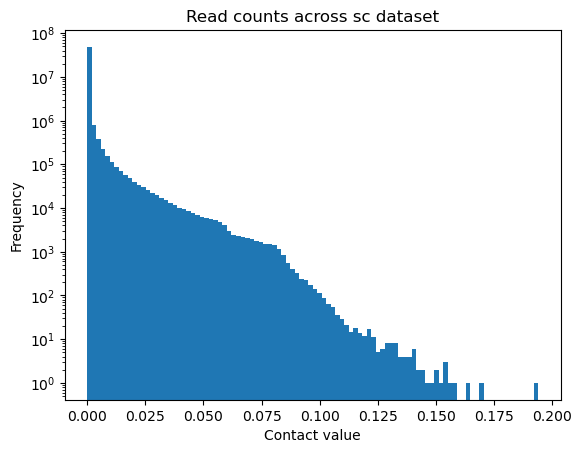

In [5]:
### Plotting ###
plt.hist(non_zero, log=True, bins=100)
plt.title("Read counts across sc dataset")
plt.xlabel("Contact value")
plt.ylabel("Frequency")

## Plotting thresholds

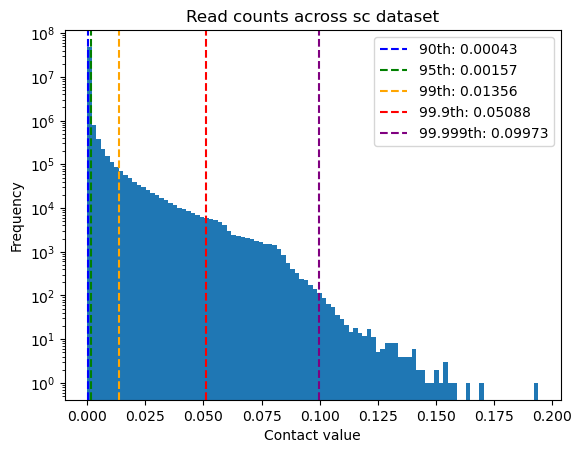

In [6]:
### Calculating and plotting percentiles ###
    # Calculating
percentiles = [90, 95, 99, 99.9, 99.999]
pvals = np.percentile(non_zero, percentiles)

    # Plotting
colors = ['blue', 'green', 'orange', 'red', 'purple']
for p, val, c in zip(percentiles, pvals, colors):
    plt.axvline(val, linestyle='--', color=c, label=f'{p}th: {val:.5f}')

plt.hist(non_zero, log=True, bins=100)
plt.title("Read counts across sc dataset")
plt.xlabel("Contact value")
plt.ylabel("Frequency")
plt.legend()

## Plotting Remaining Counts
To invesitage how much data is trimmed from thresholding, we'll apply a threshold to each cell individually and assess the number of remaining reads

In [25]:
### Thresholding data ###
threshold_data = {}
for p in percentiles:
    comb_vals = []
    for chr1 in sc_chr1s:
        comb_vals.append(hic_mask_threshold(chr1, p, 'percentile')[0])
    threshold_data[p] = comb_vals

In [28]:
### Converting to counts ###
counts_data = {}

for p, data in threshold_data.items():
    totals = [len(values) for values in data]
    counts_data[p] = totals

counts_df = pd.DataFrame(counts_data)
counts_df

,90.000,95.000,99.000,99.900,99.999
0,539,259,59,6,0
1,742,360,75,8,0
2,1460,692,127,9,0
3,320,167,38,4,0
4,465,230,52,5,0
...,...,...,...,...,...
8676,376,194,43,4,0
8677,321,169,37,4,0
8678,258,137,31,3,0
8679,982,475,98,10,0


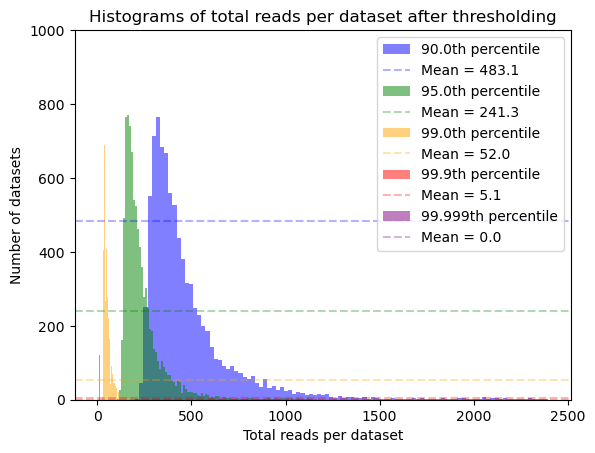

In [37]:
### Visualizing ###
plt.figure()
for p, c in zip(counts_df.columns, colors):
    plt.hist(counts_df[p], bins=100, alpha=0.5, color=c, label=f"{p}th percentile")
    mean_val = counts_df[p].mean()
    plt.axhline(mean_val, color=c, linestyle='--', alpha=0.3, label=f"Mean = {mean_val:.1f}")

plt.xlabel("Total reads per dataset")
plt.ylabel("Number of datasets")
plt.ylim((0, 1000))
plt.title("Histograms of total reads per dataset after thresholding")
plt.legend()
plt.show()

## Heatmap 8 Mb, 0%
This is purely here for testing purposes to see if the generalized functions above produce the same results.

In [7]:
### Generating data ###
long_8mb_0 = ot_full_cell_type_comparison()

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/2613552872.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/2613552872.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/2613552872.py:67: FutureWarning: DataFrameG

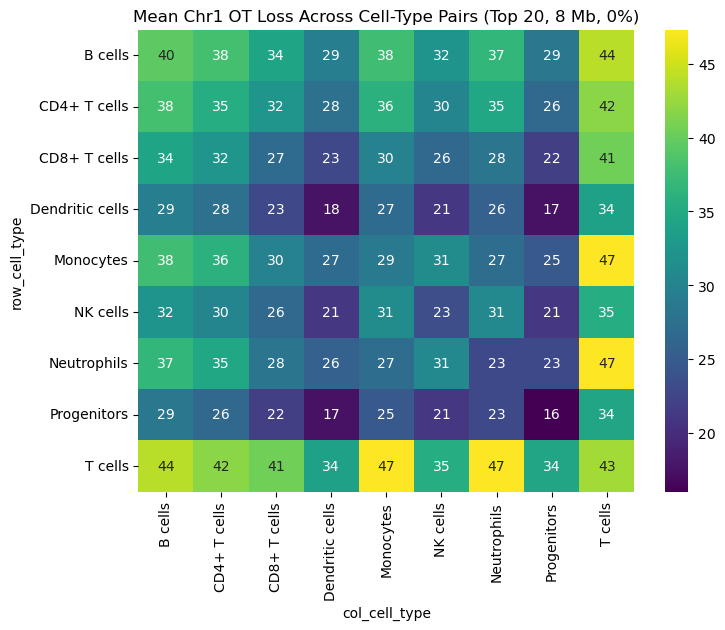

In [8]:
### Heatmap ###
generate_heatmap(long_8mb_0, 8, 0, 20)

## Heatmap 2 Mb, 90%

In [39]:
### Generating data ###
long_2mb_90 = ot_full_cell_type_comparison(2, 90, 20)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/1339440045.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/1339440045.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_61677/1339440045.py:67: FutureWarning: DataFrameG

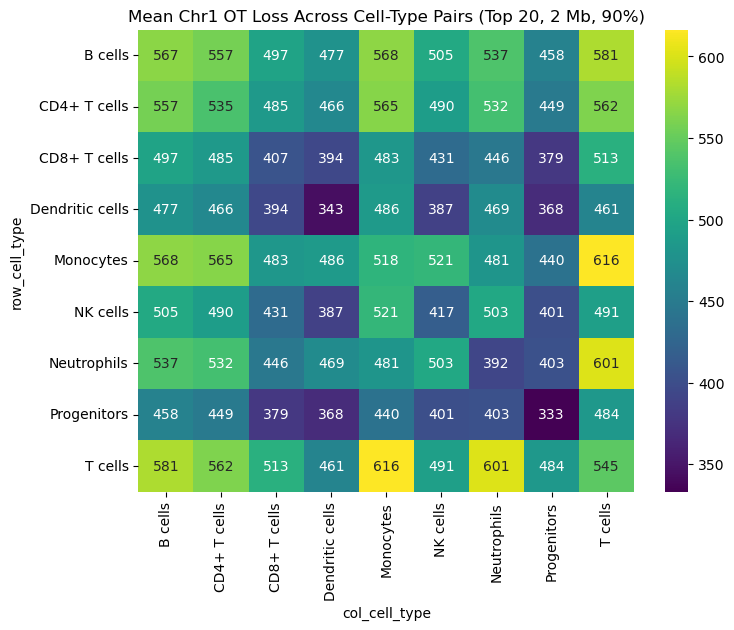

In [50]:
### Heatmap ###
generate_heatmap(long_2mb_90, 2, 90, 20)

## Heatmap 1 Mb, 90%

In [3]:
### Generating data ###
long_1mb_90 = ot_full_cell_type_comparison(1, 90, 20)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_65843/3801012071.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_65843/3801012071.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_65843/3801012071.py:67: FutureWarning: DataFrameG

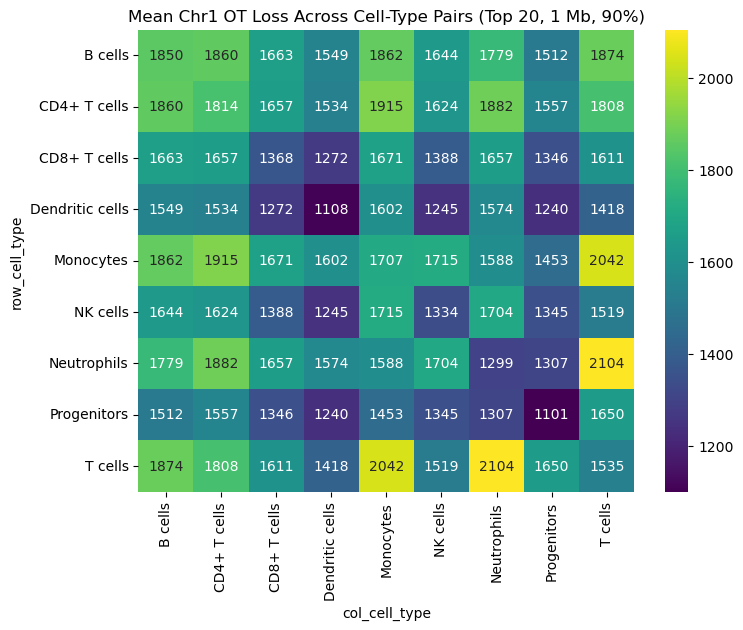

In [4]:
### Heatmap ###
generate_heatmap(long_1mb_90, 1, 90, 20)